# Figure 4: Age Effects

Top-row heatmap of age effects with focused follow-up panels for the strongest bundle-metric effect.


## Shared Setup

Loads style/config, assembled age-effect outputs, and shared export helpers.


In [1]:
#!/usr/bin/env Rscript

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(purrr)
  library(scales)
  library(viridis)
  library(arrow)
  library(patchwork)
  library(grid)
  # hexbin removed
})

# Locate config.json (CONFIG_PATH env or . / .. / ../..)
config_candidates <- c(
  Sys.getenv("CONFIG_PATH", unset = ""),
  fs::path(".", "config.json"),
  fs::path("..", "config.json"),
  fs::path("..", "..", "config.json")
)
config_candidates <- normalizePath(unique(config_candidates[nzchar(config_candidates)]), winslash = "/", mustWork = FALSE)
config_path <- config_candidates[file_exists(config_candidates)][1]
if (is.na(config_path) || !nzchar(config_path)) stop("Could not locate config.json. Set CONFIG_PATH or run from project tree.")
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file_exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure4_dir <- fs::path(project_root, "figures", "Figure4")
fs::dir_create(figure4_dir, recurse = TRUE)
fs::dir_create(fs::path(figure4_dir, "panels"), recurse = TRUE)

figure_width_mm <- 220
figure_height_max_mm <- 210
figure_width_in <- figure_width_mm / 25.4

panel_width_mm <- 88
panel_width_in <- panel_width_mm / 25.4
panel_height_in <- panel_width_in * 0.96
heatmap_tile_height <- 1.00
heatmap_height_scale <- 0.58
heatmap_height_in <- panel_height_in * heatmap_height_scale

# Export dimensions. Panel A uses taller standalone height so heatmap x-axis labels don't overlap.
panel_export_width_a_in <- figure_width_in
panel_export_height_a_in <- 4
panel_export_width_bc_in <- figure_width_in / 2
panel_export_height_bc_in <- panel_height_in

axis_title_pt <- 7
axis_text_pt <- 6
plot_title_pt <- 7
legend_title_pt <- 6
legend_text_pt <- 6

# Age effects from scripts/4_age_effects (pooled, harmonized, no_quality covariate)
qc_target <- "no_quality"
source_target <- "harmonized"
output_target <- "pooled"
scanner_target <- "all"

metrics_keep <- c("DKI_mkt", "NODDI_icvf", "MAPMRI_rtop", "GQI_fa", "GQI_md")
metric_labels <- c(
  "DKI_mkt" = "MKT",
  "NODDI_icvf" = "ICVF",
  "MAPMRI_rtop" = "RTOP",
  "GQI_fa" = "FA",
  "GQI_md" = "MD"
)
metric_label_levels <- unname(metric_labels)

metric_colors <- metric_colors[metric_label_levels]
if (any(is.na(metric_colors))) {
  stop("Missing metric colors for: ", paste(names(metric_colors)[is.na(metric_colors)], collapse = ", "))
}
metric_fill_colors <- scales::alpha(metric_colors, 0.22)

if (!all(c("Association", "ProjectionBasalGanglia", "ProjectionBrainstem", "Cerebellum", "Commissure") %in% names(bundle_colors))) {
  stop("bundle_colors in plot_style.R is missing one or more required categories.")
}

# category_label_map, category_order_pretty, bundle_color_pretty from plot_style.R

highlight_blue <- "#79BDEB"

make_panel_theme <- function(legend_position = "none", placed_width_in = panel_width_in) {
  make_theme_pub(
    style = plot_style,
    legend_position = legend_position,
    axis_title_pt = pt_for_export(axis_title_pt, placed_width_in, placed_width_in),
    axis_text_pt = pt_for_export(axis_text_pt, placed_width_in, placed_width_in),
    plot_title_pt = pt_for_export(plot_title_pt, placed_width_in, placed_width_in),
    legend_title_pt = pt_for_export(legend_title_pt, placed_width_in, placed_width_in),
    legend_text_pt = pt_for_export(legend_text_pt, placed_width_in, placed_width_in),
    base_size_pt = 11
  ) +
    theme(text = element_text(family = font_family_use))
}

# save_plot_outputs() from plot_style.R; pass out_dir = figure4_dir

age_effect_file <- fs::path(project_root, "data", "age_effects", "age_effects_all_outputs.rds")
if (!file_exists(age_effect_file)) stop("Missing assembled age-effect file: ", age_effect_file)

df_age_all <- readRDS(age_effect_file)
required_age_cols <- c(
  "bundle", "bundle_category", "metric", "qc_metric",
  "source", "output_type", "scanner_manufacturer", "age_effect_size"
)
if (!all(required_age_cols %in% names(df_age_all))) {
  stop(
    "Assembled age-effect data missing required columns: ",
    paste(setdiff(required_age_cols, names(df_age_all)), collapse = ", ")
  )
}

df_age <- df_age_all %>%
  filter(
    qc_metric == qc_target,
    source == source_target,
    output_type == output_target,
    scanner_manufacturer == scanner_target,
    metric %in% metrics_keep,
    !is.na(bundle),
    !is.na(bundle_category),
    !is.na(age_effect_size)
  ) %>%
  mutate(
    metric_label = unname(metric_labels[metric]),
    bundle_category_raw = bundle_category,
    bundle_category_pretty = recode(bundle_category, !!!category_label_map),
    bundle_clean = bundle %>%
      str_replace("FrontoOccipital", "Fronto-Occipital") %>%
      str_replace("NonDecussating", "Non-Decussating") %>%
      str_replace("L$", " (L)") %>%
      str_replace("R$", " (R)") %>%
      str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
  )

if (nrow(df_age) == 0) {
  stop("No rows found for Figure 4 with filters: harmonized + pooled + no_quality + metrics_keep.")
}



## Panel A (Top Row): Age-Effect Heatmap

Harmonized no-quality age effects across bundles and five core microstructural metrics, with the max-effect cell outlined.


[INFO] Panel A max age effect: metric=NODDI_icvf | bundle=SuperiorLongitudinalFasciculusL | category=Association | age_effect_size=0.5206



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/panels/Figure4_panel_a_age_effect_heatmap.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/panels/Figure4_panel_a_age_effect_heatmap.png



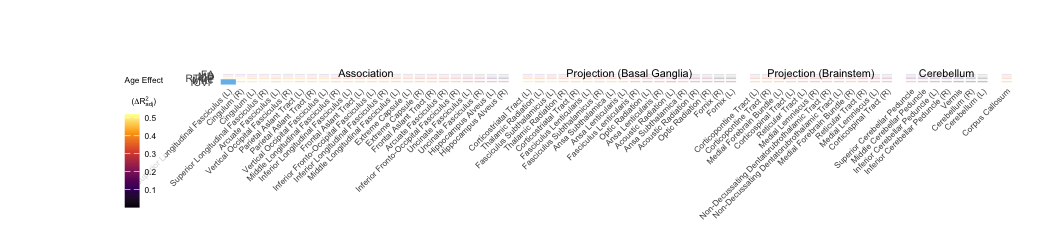

In [2]:
# Panel A -----------------------------------------------------------------

metric_order <- df_age %>%
  group_by(metric_label) %>%
  summarise(mean_effect = mean(age_effect_size, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(mean_effect)) %>%
  pull(metric_label)

df_heat <- df_age %>%
  mutate(metric_label = factor(metric_label, levels = metric_order))

bundle_df <- df_heat %>%
  group_by(bundle_category_pretty, bundle_clean, bundle, bundle_category_raw) %>%
  summarise(mean_effect = mean(age_effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(bundle_category_pretty = factor(bundle_category_pretty, levels = category_order_pretty)) %>%
  arrange(bundle_category_pretty, desc(mean_effect), bundle_clean)

bundle_levels <- c()
for (cat in category_order_pretty) {
  cat_bundles <- bundle_df %>% filter(bundle_category_pretty == cat) %>% pull(bundle_clean)
  if (length(cat_bundles) > 0) {
    bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
  }
}
bundle_levels <- bundle_levels[!grepl("^spacer_Corpus Callosum$", bundle_levels)]

df_heat <- df_heat %>%
  mutate(bundle_clean = factor(bundle_clean, levels = bundle_levels))

highlight_cell <- df_heat %>%
  arrange(desc(age_effect_size)) %>%
  slice(1) %>%
  select(
    bundle_clean, metric_label, metric, bundle, bundle_category_raw,
    bundle_category_pretty, age_effect_size
  )

if (nrow(highlight_cell) != 1) {
  stop("Could not identify a unique max age-effect heatmap cell.")
}

highlight_metric <- as.character(highlight_cell$metric[[1]])
highlight_metric_label <- as.character(highlight_cell$metric_label[[1]])
highlight_bundle <- as.character(highlight_cell$bundle[[1]])
highlight_bundle_category_raw <- as.character(highlight_cell$bundle_category_raw[[1]])
highlight_bundle_clean <- as.character(highlight_cell$bundle_clean[[1]])
highlight_effect <- as.numeric(highlight_cell$age_effect_size[[1]])

message(
  "[INFO] Panel A max age effect: metric=", highlight_metric,
  " | bundle=", highlight_bundle,
  " | category=", highlight_bundle_category_raw,
  " | age_effect_size=", signif(highlight_effect, 4)
)

spacer_df <- expand.grid(
  bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
  metric_label = metric_order
) %>%
  mutate(age_effect_size = NA_real_)

df_heat_plot <- bind_rows(
  df_heat %>% select(bundle_clean, metric_label, age_effect_size),
  spacer_df
)

x_labels <- levels(df_heat_plot$bundle_clean)
x_labels[grepl("^spacer_", x_labels)] <- ""

bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
cat_positions <- bundle_df %>%
  group_by(bundle_category_pretty) %>%
  summarise(
    xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmid = mean(c(xmin, xmax)),
    .groups = "drop"
  ) %>%
  filter(bundle_category_pretty != "Corpus Callosum")

heatmap_export_width_in <- figure_width_in
heatmap_final_width_in <- figure_width_in

p_panel_a <- ggplot(df_heat_plot, aes(x = bundle_clean, y = metric_label, fill = age_effect_size)) +
  geom_tile(color = "white", linewidth = 0.45, height = heatmap_tile_height) +
  geom_tile(
    data = highlight_cell,
    aes(x = bundle_clean, y = metric_label),
    fill = NA,
    color = highlight_blue,
    linewidth = 0.95,
    width = 0.98,
    height = heatmap_tile_height,
    inherit.aes = FALSE
  ) +
  scale_fill_viridis_c(
    option = "inferno",
    name = expression(atop("Age Effect", "(" * Delta * R[adj]^2 * ")")),
    na.value = "white"
  ) +
  guides(fill = guide_colorbar(
    barheight = unit(length(metric_order) * heatmap_tile_height * 0.78, "lines"),
    barwidth = unit(0.62, "lines")
  )) +
  scale_x_discrete(labels = x_labels, expand = expansion(add = 0.8)) +
  scale_y_discrete(expand = expansion(mult = c(0, 0))) +
  coord_cartesian(clip = "off") +
  labs(x = NULL, y = NULL) +
  theme_minimal(
    base_family = font_family_use,
    base_size = pt_for_export(axis_text_pt, heatmap_export_width_in, heatmap_final_width_in)
  ) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(
      angle = 45, hjust = 1, vjust = 1,
      size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)
    ),
    axis.text.y = element_text(size = pt_for_export(axis_text_pt + 0.2, heatmap_export_width_in, heatmap_final_width_in)),
    axis.ticks = element_blank(),
    plot.margin = margin(44, 14, 6, 112),
    legend.title = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
    legend.text = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
legend.background = element_rect(fill = scales::alpha("white", 0.76), color = NA),
legend.box.background = element_blank(),
    legend.position = c(-0.12, 0.97),
    legend.justification = c(0, 1),
    legend.direction = "vertical",
    legend.margin = margin(1, 1, 1, 1),
    panel.background = element_rect(fill = plot_style$panel_background_fill, color = NA),
    plot.background = element_rect(fill = plot_style$plot_background_fill, color = NA),
    panel.border = element_blank()
  )

y_top <- length(metric_order) + 0.82
for (i in seq_len(nrow(cat_positions))) {
  p_panel_a <- p_panel_a + annotate(
    "text",
    x = cat_positions$xmid[i],
    y = y_top,
    label = cat_positions$bundle_category_pretty[i],
    family = font_family_use,
    size = pt_for_export(axis_text_pt + 0.5, heatmap_export_width_in, heatmap_final_width_in) / .pt
  )
}

options(repr.plot.width = figure_width_in, repr.plot.height = heatmap_height_in, repr.plot.res = 120)
p_panel_a
save_plot_outputs(p_panel_a, "Figure4_panel_a_age_effect_heatmap", fs::path(figure4_dir, "panels"), panel_export_width_a_in, panel_export_height_a_in, allow_sans_fallback = FALSE)



## Panel B (Bottom Left): Age Curve

GAMM median age curve for the highlighted bundle-metric over individual values (scatter).


[INFO] Saved panel B cache: /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/Figure4_panel_b_cache.rds

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/panels/Figure4_panel_b_age_curve_scatter.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/panels/Figure4_panel_b_age_curve_scatter.png



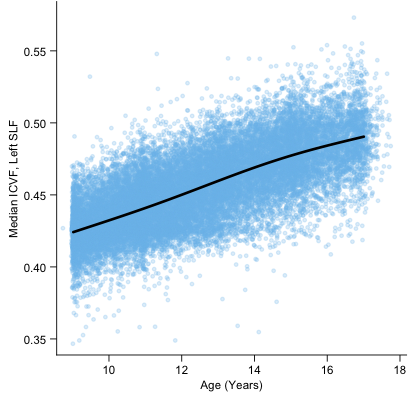

In [3]:
# Panel B -----------------------------------------------------------------

harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
if (!file_exists(harm_path)) stop("Missing harmonized parquet: ", harm_path)

harm_cols <- arrow::open_dataset(harm_path, format = "parquet")$schema$names
bundle_col <- paste0(
  "bundle_",
  highlight_bundle_category_raw,
  "_",
  highlight_bundle,
  "_",
  highlight_metric,
  "_median"
)

if (!bundle_col %in% harm_cols) {
  fallback_hits <- harm_cols[str_detect(harm_cols, fixed(paste0("_", highlight_bundle, "_", highlight_metric, "_median")))]
  if (length(fallback_hits) == 0) {
    stop("Could not locate panel B bundle column: ", bundle_col)
  }
  bundle_col <- fallback_hits[1]
  message("[WARN] Using fallback panel B bundle column: ", bundle_col)
}

panel_b_cache_file <- fs::path(figure4_dir, "Figure4_panel_b_cache.rds")
panel_b_cache_key <- list(
  source = source_target,
  output_type = output_target,
  qc_metric = qc_target,
  scanner_manufacturer = scanner_target,
  metric = highlight_metric,
  bundle = highlight_bundle,
  bundle_category = highlight_bundle_category_raw,
  bundle_col = bundle_col,
  harmonized_mtime = as.character(file.info(harm_path)$mtime),
  gam_no_site = TRUE
)

df_panel_b <- NULL
curve_df <- NULL
cache_used <- FALSE

if (file_exists(panel_b_cache_file)) {
  cache_obj <- tryCatch(readRDS(panel_b_cache_file), error = function(e) NULL)
  if (
    is.list(cache_obj) &&
      identical(cache_obj$key, panel_b_cache_key) &&
      is.data.frame(cache_obj$df_panel_b) &&
      is.data.frame(cache_obj$curve_df) &&
      all(c("age", "pred_median", "lower", "upper") %in% names(cache_obj$curve_df))
  ) {
    df_panel_b <- cache_obj$df_panel_b
    curve_df <- cache_obj$curve_df
    cache_used <- TRUE
    message("[INFO] Loaded panel B cached model inputs/predictions: ", panel_b_cache_file)
  } else {
    message("[INFO] Panel B cache exists but key/data mismatch; recomputing.")
  }
}

if (!cache_used) {
  df_panel_b <- arrow::read_parquet(
    harm_path,
    col_select = all_of(c("subject_id", "site", "sex", "age", bundle_col))
  ) %>%
    as_tibble() %>%
    transmute(
      subject_id = factor(subject_id),
      site = factor(site),
      sex = factor(sex),
      age = as.numeric(age),
      value = as.numeric(.data[[bundle_col]])
    ) %>%
    filter(!is.na(value), !is.na(age), !is.na(site), !is.na(sex), !is.na(subject_id))

  if (nrow(df_panel_b) < 100) {
    stop("Insufficient rows for panel B model fit (n < 100).")
  }

  if (!requireNamespace("gamm4", quietly = TRUE)) {
    stop("Panel B requires package 'gamm4' for the specified random-slope model.")
  }

  full_mod <- tryCatch(
    gamm4::gamm4(
      formula = value ~ s(age, k = 4) + sex,
      random = ~(1 + age | subject_id),
      data = df_panel_b
    ),
    error = function(e) {
      stop("Panel B model failed: ", conditionMessage(e))
    }
  )

  age_grid <- seq(
    quantile(df_panel_b$age, 0.01, na.rm = TRUE),
    quantile(df_panel_b$age, 0.99, na.rm = TRUE),
    length.out = 220
  )
  pred_grid <- expand.grid(
    age = age_grid,
    sex = levels(df_panel_b$sex),
    KEEP.OUT.ATTRS = FALSE,
    stringsAsFactors = FALSE
  )
  pred_out <- predict(full_mod$gam, newdata = pred_grid, se.fit = TRUE)
  pred_grid$pred <- as.numeric(pred_out$fit)
  pred_grid$se <- as.numeric(pred_out$se.fit)
  curve_df <- pred_grid %>%
    group_by(age) %>%
    summarise(
      pred_median = median(pred, na.rm = TRUE),
      se_median = median(se, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(
      lower = pred_median - 1.96 * se_median,
      upper = pred_median + 1.96 * se_median
    )

  saveRDS(
    list(
      key = panel_b_cache_key,
      df_panel_b = df_panel_b,
      curve_df = curve_df
    ),
    panel_b_cache_file
  )
  message("[INFO] Saved panel B cache: ", panel_b_cache_file)
}

if (nrow(df_panel_b) < 100) {
  stop("Panel B data has fewer than 100 rows after cache load/recompute.")
}

panel_b_ylabel <- "Median ICVF, Left SLF"
if (!(identical(highlight_metric, "NODDI_icvf") && identical(highlight_bundle, "SuperiorLongitudinalFasciculusL"))) {
  bundle_label_fallback <- highlight_bundle %>%
    str_replace("L$", " (L)") %>%
    str_replace("R$", " (R)") %>%
    str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
  panel_b_ylabel <- paste0("Median ", highlight_metric_label, ", ", bundle_label_fallback)
}

p_panel_b_scatter <- ggplot(df_panel_b, aes(x = age, y = value)) +
  geom_point(color = highlight_blue, size = 0.70, alpha = 0.24) +
  geom_ribbon(
    data = curve_df,
    aes(x = age, ymin = lower, ymax = upper),
    inherit.aes = FALSE,
    fill = "grey70",
    alpha = 0.35
  ) +
  geom_line(
    data = curve_df,
    aes(x = age, y = pred_median),
    inherit.aes = FALSE,
    color = "black",
    linewidth = 0.75,
    lineend = "round"
  ) +
  labs(
    x = "Age (Years)",
    y = panel_b_ylabel
  ) +
  coord_cartesian(xlim = c(9, NA), ylim = c(0.35, NA)) +
  make_panel_theme(legend_position = "none", placed_width_in = panel_width_in) +
  theme(
    panel.grid.minor = element_blank(),
    axis.title = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    axis.text = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    axis.line = element_line(linewidth = 0.25, color = "black"),
    axis.ticks = element_line(linewidth = 0.25, color = "black"),
    plot.margin = margin(1, 5.5, 5.5, 5.5)
  )

options(repr.plot.width = panel_width_in, repr.plot.height = panel_height_in, repr.plot.res = 120)
p_panel_b_scatter
save_plot_outputs(p_panel_b_scatter, "Figure4_panel_b_age_curve_scatter", fs::path(figure4_dir, "panels"), panel_export_width_bc_in, panel_export_height_bc_in)



## Panel C (Bottom Right): Age-Effect Distributions

Metric-wise violins of bundle age effects with bundle-category dots and legend.


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/panels/Figure4_panel_c_age_effect_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/panels/Figure4_panel_c_age_effect_violin.png



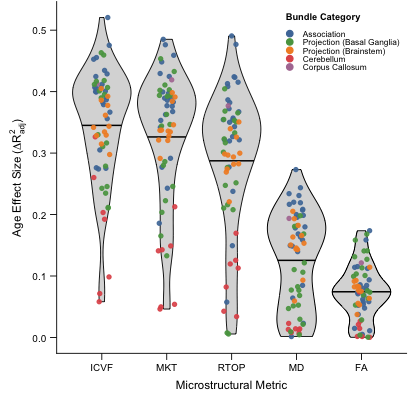

In [4]:
# Panel C -----------------------------------------------------------------

df_panel_c <- df_age %>%
  transmute(
    metric_label = metric_label,
    bundle = bundle,
    bundle_category_pretty = factor(bundle_category_pretty, levels = category_order_pretty),
    age_effect_size = age_effect_size
  ) %>%
  filter(!is.na(metric_label), !is.na(bundle_category_pretty), !is.na(age_effect_size))

metric_order_c <- df_panel_c %>%
  group_by(metric_label) %>%
  summarise(mean_effect = mean(age_effect_size, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(mean_effect)) %>%
  pull(metric_label)

df_panel_c <- df_panel_c %>%
  mutate(metric_label = factor(metric_label, levels = metric_order_c))

violin_fill_values <- metric_fill_colors[levels(df_panel_c$metric_label)]
if (any(is.na(violin_fill_values))) {
  stop("Panel C violin fill colors missing for one or more metric labels.")
}

metric_breaks_c <- seq_along(levels(df_panel_c$metric_label))
metric_labels_c <- levels(df_panel_c$metric_label)

df_panel_c <- df_panel_c %>%
  mutate(metric_idx = as.numeric(metric_label))

mean_segment_df <- df_panel_c %>%
  group_by(metric_label, metric_idx) %>%
  summarise(mean_effect = mean(age_effect_size, na.rm = TRUE), .groups = "drop")

violin_geom <- ggplot_build(
  ggplot(df_panel_c, aes(x = metric_idx, y = age_effect_size, group = metric_label)) +
    geom_violin(width = 0.90, trim = TRUE, scale = "width")
)$data[[1]] %>%
  mutate(metric_idx = as.numeric(group))

mean_segment_df <- mean_segment_df %>%
  mutate(
    width_frac = purrr::map2_dbl(metric_idx, mean_effect, function(idx, mean_val) {
      this_geom <- violin_geom %>% filter(metric_idx == idx)
      if (nrow(this_geom) == 0) return(0)
      out <- stats::approx(
        x = this_geom$y,
        y = this_geom$violinwidth,
        xout = mean_val,
        rule = 2
      )$y
      if (!is.finite(out)) 0 else as.numeric(out)
    }),
    half_width = purrr::map_dbl(metric_idx, function(idx) {
      this_geom <- violin_geom %>% filter(metric_idx == idx)
      if (nrow(this_geom) == 0) return(0)
      max(this_geom$xmax - this_geom$x, na.rm = TRUE)
    }) * width_frac,
    x_start = metric_idx - half_width,
    x_end = metric_idx + half_width
  )

p_panel_c <- ggplot(df_panel_c, aes(x = metric_idx, y = age_effect_size)) +
  geom_violin(
    aes(group = metric_label),
    color = "black",
    linewidth = 0.25,
    width = 0.90,
    trim = TRUE,
    scale = "width",
    fill = scales::alpha("grey70", 0.50)
  ) +
  geom_segment(
    data = mean_segment_df,
    aes(x = x_start, xend = x_end, y = mean_effect, yend = mean_effect),
    inherit.aes = FALSE,
    color = "black",
    linewidth = 0.42
  ) +
  geom_jitter(
    aes(color = bundle_category_pretty),
    width = 0.13,
    height = 0,
    size = 0.85,
    alpha = 0.9
  ) +
  scale_x_continuous(breaks = metric_breaks_c, labels = metric_labels_c) +
  scale_color_manual(
    values = bundle_color_pretty,
    name = "Bundle Category",
    drop = FALSE
  ) +
  guides(
    color = guide_legend(
      override.aes = list(size = 1.5, alpha = 1),
      ncol = 1,
      byrow = TRUE
    )
  ) +
  labs(
    x = "Microstructural Metric",
    y = expression("Age Effect Size (" * Delta * R[adj]^2 * ")")
  ) +
  make_panel_theme(legend_position = c(0.985, 0.975), placed_width_in = panel_width_in) +
  theme(
    panel.grid.minor = element_blank(),
    axis.line = element_line(linewidth = 0.25, color = "black"),
    axis.ticks = element_line(linewidth = 0.25, color = "black"),
    axis.title = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    axis.text = element_text(size = pt_for_export(6, panel_width_in, panel_width_in)),
    legend.title = element_text(face = "bold", size = pt_for_export(5.6, panel_width_in, panel_width_in), lineheight = 0.9),
    legend.text = element_text(size = pt_for_export(5.0, panel_width_in, panel_width_in)),
    legend.justification = c(1, 1),
    legend.key.height = unit(4.6, "pt"),
    legend.key.width = unit(4.8, "pt"),
    legend.spacing.y = unit(1.0, "pt"),
    legend.margin = margin(1, 1, 1, 1),
    legend.box.spacing = unit(0, "pt"),
    legend.background = element_rect(fill = scales::alpha("white", 0.95), color = NA),
    legend.box.background = element_blank(),
    plot.margin = margin(1, 5.5, 5.5, 5.5)
  )

options(repr.plot.width = panel_width_in, repr.plot.height = panel_height_in, repr.plot.res = 120)
p_panel_c
save_plot_outputs(p_panel_c, "Figure4_panel_c_age_effect_violin", fs::path(figure4_dir, "panels"), panel_export_width_bc_in, panel_export_height_bc_in)



## ABC Layout Preview

Panel A full-width on top, Panels B/C side-by-side on the bottom row.


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/Figure4_combined_abc_preview.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure4/Figure4_combined_abc_preview.png



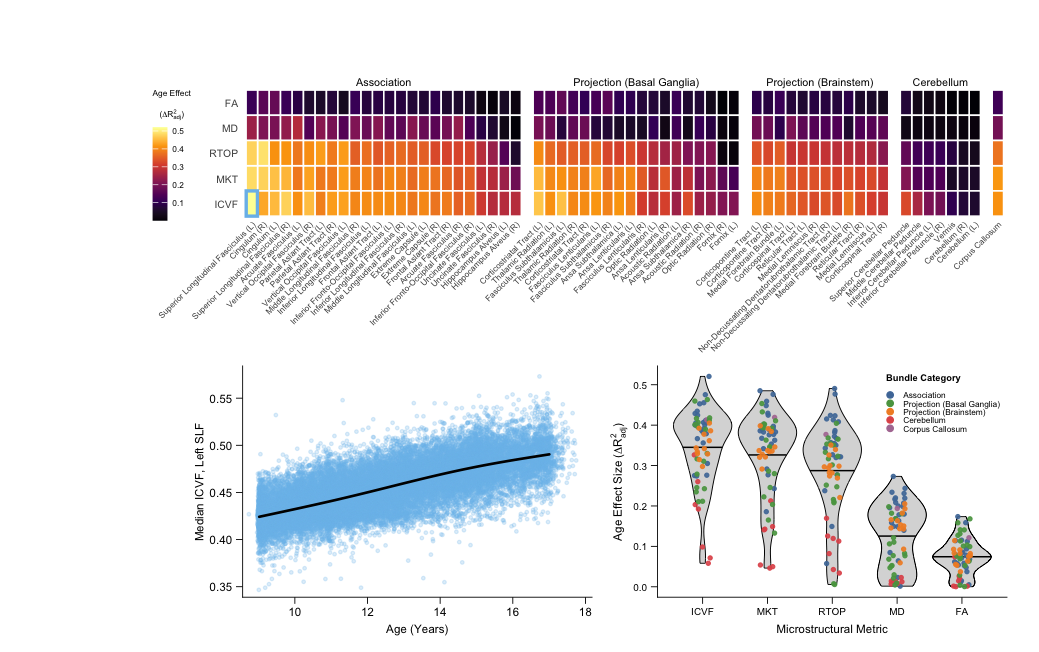

In [5]:
# Combined ABC layout ------------------------------------------------------

figure4_abc <- (p_panel_a / (p_panel_b_scatter | p_panel_c)) +
  patchwork::plot_layout(heights = c(heatmap_height_in, panel_height_in), widths = c(1, 1))

combined_height_in <- min(figure_height_max_mm / 25.4, heatmap_height_in + panel_height_in + 0.18)

options(repr.plot.width = figure_width_in, repr.plot.height = combined_height_in, repr.plot.res = 120)
figure4_abc
save_plot_outputs(figure4_abc, "Figure4_combined_abc_preview", figure4_dir, figure_width_in, combined_height_in)
